# TartuBid &mdash; Prototype Evidence

This notebook reproduces the results shown in the **Prototype evidence** block of our poster *TartuBid: Clock Synchronization in a Distributed Online Auction* (LTAT.06.007 Distributed Systems, University of Tartu, Spring 2026).

**Team:** Anup Kumar &nbsp;&middot;&nbsp; Md Mumin Ul Bari &nbsp;&middot;&nbsp; Sten (Qun-yan Li)

---

## What this notebook shows

We replay the failure scenario from the **Introduction** of the poster &mdash; two auction servers with deliberately skewed clocks, two bids placed close to a deadline &mdash; and resolve the auction winner under four different clock-synchronisation strategies.

| Strategy | Expected outcome |
|---|---|
| Na&iuml;ve (no sync) | hands the auction to the *late* bidder |
| NTP | recovers the correct winner |
| Berkeley | recovers the correct winner |
| TrueTime | refuses to commit (commit-wait) |

All four resolvers live in [`clock_sync.py`](clock_sync.py). The notebook is intended to be self-explanatory &mdash; run the cells top-to-bottom.

## 1. Imports and dependencies

We use only the standard library plus `pandas` and `matplotlib` for the summary table and the timeline plot. The four resolver classes are imported from the local `clock_sync` module.

In [1]:
from clock_sync import (
    Bid,
    NaiveResolver,
    NTPResolver,
    BerkeleyResolver,
    TrueTimeResolver,
)

import pandas as pd
import matplotlib.pyplot as plt

## 2. The scenario

Two auction servers, two bidders, one deadline:

* **eu-west** &mdash; clock runs **+80 ms fast** vs. true UTC.
* **us-east** &mdash; clock runs **−60 ms slow** vs. true UTC.
* **Anup** places a bid of **100 EUR** on eu-west, at true UTC **−40 ms** (on time).
* **Mumin** places a bid of **110 EUR** on us-east, at true UTC **+30 ms** (late).

Each server stamps the bid with its **own local clock** &mdash; so what each server records is biased by its skew. The coordinator wakes up 500 ms after the true deadline and queries each server for its clock and bid log.

We pick a round-number reference time for readability: the true UTC deadline is `1_000_000.000`.

In [2]:
# --- scenario parameters ---------------------------------------------
deadline_utc       = 1_000_000.000   # true UTC instant when the auction closes
coordinator_clock  = 1_000_000.500   # coordinator wakes up 500 ms after the deadline

skew = {
    "eu-west": +0.080,    # +80 ms fast
    "us-east": -0.060,    # -60 ms slow
}

# the local clock the coordinator reads from each server at sync time
server_clocks = {sid: coordinator_clock + s for sid, s in skew.items()}

# --- the two bids, as each server actually recorded them -------------
bids = [
    Bid(bidder="Anup",  amount=100.0, server_id="eu-west",
        server_local_time=999_999.970 + skew["eu-west"]),    # true -40 ms
    Bid(bidder="Mumin", amount=110.0, server_id="us-east",
        server_local_time=1_000_000.030 + skew["us-east"]),  # true +30 ms
]

# coordinator's NTP-style offset estimate for each server
offsets_ntp = {sid: clk - coordinator_clock for sid, clk in server_clocks.items()}

print(f"Auction deadline (true UTC):       {deadline_utc:.3f}")
print(f"Coordinator clock at resolution:   {coordinator_clock:.3f}\n")
print("Recorded bids:")
for b in bids:
    print(f"  {b.bidder:6} {b.amount:>6.2f} EUR via {b.server_id}  (server-local stamp {b.server_local_time:.3f})")
print(f"\nNTP-style offsets vs coordinator: {offsets_ntp}")

Auction deadline (true UTC):       1000000.000
Coordinator clock at resolution:   1000000.500

Recorded bids:
  Anup   100.00 EUR via eu-west  (server-local stamp 1000000.050)
  Mumin  110.00 EUR via us-east  (server-local stamp 999999.970)

NTP-style offsets vs coordinator: {'eu-west': 0.07999999995809048, 'us-east': -0.060000000055879354}


Notice what the local timestamps actually look like in the recorded bids:

* Anup's bid at eu-west: true `-40 ms`, but eu-west's clock is `+80 ms` fast, so the server-local stamp is `+40 ms` &mdash; *after* the deadline on the server's own clock.
* Mumin's bid at us-east: true `+30 ms`, but us-east's clock is `-60 ms` slow, so the server-local stamp is `-30 ms` &mdash; *before* the deadline on the server's own clock.

So a coordinator that trusts the raw local stamps will see exactly the opposite of the truth.

## 3. Strategy 1 &mdash; Naïve (no clock sync)

Each bid is accepted iff its **server-local** stamp is &le; the deadline. No correction is applied. This is the baseline we expect to fail.

In [3]:
res = NaiveResolver(deadline_utc).resolve(bids)

print(f"Strategy : {res.strategy}")
if res.winner is None:
    print(f"Winner   : -- no commit --")
else:
    print(f"Winner   : {res.winner.bidder} ({res.winner.amount:.0f} EUR) via {res.winner.server_id}")
if res.note:
    print(f"Note     : {res.note}")

Strategy : Naive (no sync)
Winner   : Mumin (110 EUR) via us-east


**Mumin wins** &mdash; even though his bid was placed *after* the true deadline. The slow `us-east` clock made his late bid appear on time. This is the unfair outcome the poster sets out to prevent.

## 4. Strategy 2 &mdash; NTP

The coordinator estimates each server's offset against itself (a stand-in for a stratum-*n* reference exchange) and rewrites every bid's timestamp onto the coordinator's reference timeline before comparing against the deadline.

We pass the offsets in directly; in a real deployment they would be measured via the four-timestamp exchange:

$$\theta = \frac{(t_2 - t_1) + (t_3 - t_4)}{2}, \quad \delta = (t_4 - t_1) - (t_3 - t_2).$$

In [4]:
res = NTPResolver(deadline_utc, offsets_ntp).resolve(bids)

print(f"Strategy : {res.strategy}")
if res.winner is None:
    print(f"Winner   : -- no commit --")
else:
    print(f"Winner   : {res.winner.bidder} ({res.winner.amount:.0f} EUR) via {res.winner.server_id}")
if res.note:
    print(f"Note     : {res.note}")

Strategy : NTP
Winner   : Anup (100 EUR) via eu-west


**Anup wins** &mdash; the correct outcome. After NTP-style correction, Mumin's stamp moves to `+30 ms` (true position) and is rejected as late; Anup's stamp moves to `-40 ms` and is accepted.

## 5. Strategy 3 &mdash; Berkeley algorithm

Berkeley does not require an external UTC source. A daemon (here, the coordinator) polls every server's clock, averages them with its own, and tells each server how to adjust. We apply the same adjustment to the recorded bid stamps before comparing them to the deadline.

$$C_{\text{cons}} = \frac{1}{n}\sum_{i} C_i, \quad \Delta_i = C_{\text{cons}} - C_i.$$

In [5]:
res = BerkeleyResolver(deadline_utc, server_clocks, coordinator_clock).resolve(bids)

print(f"Strategy : {res.strategy}")
if res.winner is None:
    print(f"Winner   : -- no commit --")
else:
    print(f"Winner   : {res.winner.bidder} ({res.winner.amount:.0f} EUR) via {res.winner.server_id}")
if res.note:
    print(f"Note     : {res.note}")

Strategy : Berkeley
Winner   : Anup (100 EUR) via eu-west


**Anup wins** &mdash; also correct. Notice this happens *without* any external UTC source: averaging across the cluster is enough to expose the relative skew. (In a real deployment Berkeley would still be a poor fit for TartuBid because bidder clients are not part of the cluster &mdash; see the poster's *Comparison and our choice* block.)

## 6. Strategy 4 &mdash; TrueTime

TrueTime returns an **uncertainty interval** instead of a point-valued *now*:

$$\mathrm{TT.now}() = [\, t - \varepsilon,\; t + \varepsilon\,].$$

If a bid's timestamp interval **straddles** the deadline, TrueTime refuses to commit a winner and instead performs *commit-wait* &mdash; waits for the uncertainty to drain (about `2ε`) before deciding. We use $\varepsilon = 50\,\mathrm{ms}$ here, matching the band we adopt in the poster's chosen design.

In [6]:
res = TrueTimeResolver(deadline_utc, epsilon=0.050, offsets=offsets_ntp).resolve(bids)

print(f"Strategy : {res.strategy}")
if res.winner is None:
    print(f"Winner   : -- no commit --")
else:
    print(f"Winner   : {res.winner.bidder} ({res.winner.amount:.0f} EUR) via {res.winner.server_id}")
if res.note:
    print(f"Note     : {res.note}")

Strategy : TrueTime
Winner   : -- no commit --
Note     : commit-wait required: 2 bid(s) inside ±50.0 ms uncertainty window around deadline


**No commit yet.** Both bids' adjusted stamps fall inside the 50 ms uncertainty window around the deadline, so TrueTime correctly refuses to declare a winner immediately and would *commit-wait* for the uncertainty to drain. This is the safety property the poster's chosen design borrows from TrueTime.

## 7. Side-by-side summary

The same bid trace, four strategies, four different outcomes:

In [7]:
strategies = [
    NaiveResolver(deadline_utc),
    NTPResolver(deadline_utc, offsets_ntp),
    BerkeleyResolver(deadline_utc, server_clocks, coordinator_clock),
    TrueTimeResolver(deadline_utc, epsilon=0.050, offsets=offsets_ntp),
]

rows = []
for resolver in strategies:
    r = resolver.resolve(bids)
    if r.winner is None:
        winner_str = "— commit-wait —"
        outcome = "safe (no premature commit)"
    else:
        winner_str = f"{r.winner.bidder} ({r.winner.amount:.0f})"
        outcome = "✓ correct" if r.winner.bidder == "Anup" else "✗ wrong winner"
    rows.append({
        "Strategy": r.strategy,
        "Resolved winner": winner_str,
        "Outcome": outcome,
    })

df = pd.DataFrame(rows)
df

,Strategy,Resolved winner,Outcome
0,Naive (no sync),Mumin (110),✗ wrong winner
1,NTP,Anup (100),✓ correct
2,Berkeley,Anup (100),✓ correct
3,TrueTime,— commit-wait —,safe (no premature commit)


## 8. Visualising the failure mode

The plot below mirrors the timeline figure in the Introduction block of the poster: three parallel timelines (true UTC, eu-west's clock, us-east's clock), with each bid drawn at the position it occupies on each timeline. The dashed blue line is the auction deadline.

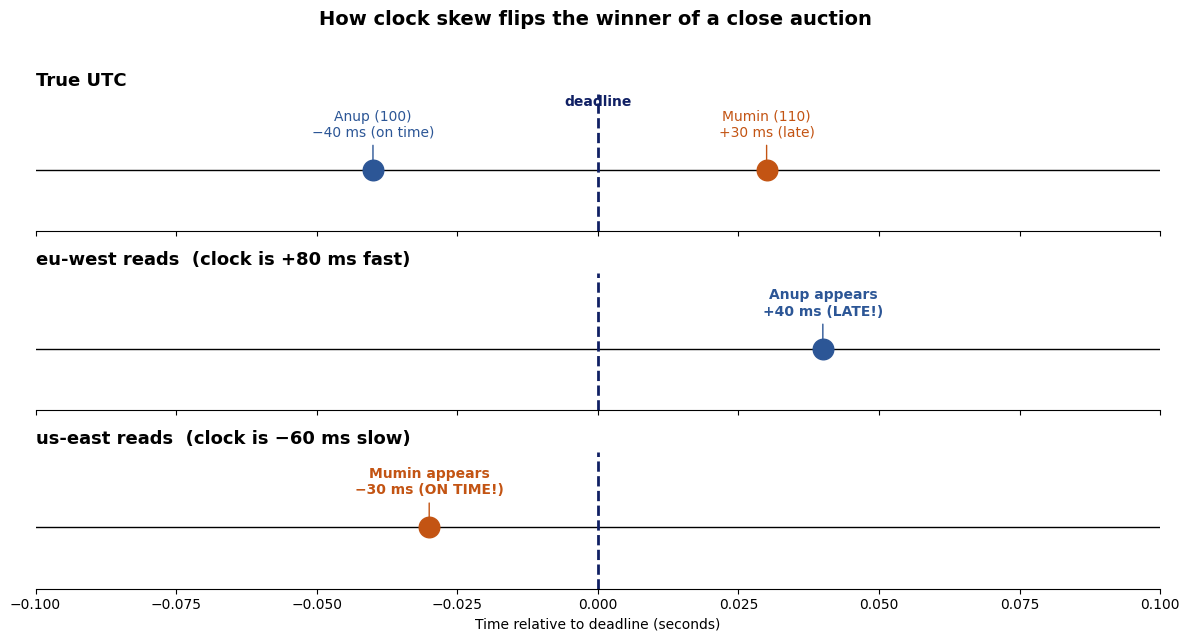

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6.5), sharex=True)

anup_color  = "#2C5696"   # MainBlue (matches poster)
mumin_color = "#C35413"   # Orange   (matches poster)
deadline_color = "#102064"

def style(ax, title):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color=deadline_color, ls="--", lw=2)
    ax.set_ylim(-1.3, 1.6)
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

# --- True UTC ---
ax = axes[0]
style(ax, "True UTC")
ax.scatter([-0.040], [0], color=anup_color,  s=220, zorder=10)
ax.annotate("Anup (100)\n−40 ms (on time)",
            xy=(-0.040, 0), xytext=(-0.040, 0.7),
            ha="center", color=anup_color, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=anup_color))
ax.scatter([0.030], [0], color=mumin_color, s=220, zorder=10)
ax.annotate("Mumin (110)\n+30 ms (late)",
            xy=(0.030, 0), xytext=(0.030, 0.7),
            ha="center", color=mumin_color, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=mumin_color))
ax.text(0, 1.35, "deadline", ha="center", color=deadline_color, fontweight="bold")

# --- eu-west reads (+80 ms fast) ---
ax = axes[1]
style(ax, "eu-west reads  (clock is +80 ms fast)")
ax.scatter([0.040], [0], color=anup_color, s=220, zorder=10)
ax.annotate("Anup appears\n+40 ms (LATE!)",
            xy=(0.040, 0), xytext=(0.040, 0.7),
            ha="center", color=anup_color, fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=anup_color))

# --- us-east reads (-60 ms slow) ---
ax = axes[2]
style(ax, "us-east reads  (clock is −60 ms slow)")
ax.scatter([-0.030], [0], color=mumin_color, s=220, zorder=10)
ax.annotate("Mumin appears\n−30 ms (ON TIME!)",
            xy=(-0.030, 0), xytext=(-0.030, 0.7),
            ha="center", color=mumin_color, fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=mumin_color))

ax.set_xlabel("Time relative to deadline (seconds)")
ax.set_xlim(-0.10, 0.10)

fig.suptitle("How clock skew flips the winner of a close auction",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 9. Conclusion

The four runs above are exactly the four rows of the *Prototype evidence* table on the poster:

* **Naïve** trusts the raw server stamps and hands the auction to the late bidder &mdash; the unfair outcome.
* **NTP** and **Berkeley** rewrite the stamps onto a consensus clock and recover the correct winner.
* **TrueTime** refuses to commit while the deadline lies inside the uncertainty interval, demonstrating the safety property that motivates our chosen design (NTP everywhere, with a TrueTime-inspired $\varepsilon = 50\,\mathrm{ms}$ band around each closing instant).

See the accompanying `documentation.md` at the project root for the full write-up of the poster and the code.